### Advanced Example: Writing an Inventory Manager

**Before moving on**

Questions on - **how to show code statements that are missed in test coverage:**
1. Display on the console `pytest --cov=calculator --cov-report term-missing`

2. Generate a test report - html report;  open the index.html file 

`pytest --cov=calculator --cov-report html`




### Substantial Case Study

Let's explore further features of `pytest` that will enable us to become more efficient at writing tests.

#### About the features and test planning
Consider a clothing and footwear store. Suppose that they would like to move management of their items from paper to a computer system. 
The store propriteor would like a software system that could perform the upcoming tasks immediately:
- Record the 10 new Nike sneakers that were recently bought. Each is worth £50.00
- Add 5 more Adidas sweatpants that cost £70.00 each.
- Store owner is expecting a customer to buy 2 of the Nike sneakers
- Store owner is expecting another customer to buy 1 of the sweatpants.

#### Let's Challenge ourselves
We try to use these requirements to create our first integration test. Before we get to writing it, let's flesh out the smaller components a bit to figure out what would be our inputs and outputs, function signatures and other system design elements.


#### What we will work with

- `inventory.py` to contain application code
- `test_inventory.py` to contain test cases 




#### Some specs
 - Each stock item has a `name`, `price` and `quantity`. 
 
**Operations:**
- add new items
- add stock to existing items
- remove stock.

**Other useful detail**
- When an Inventory object is created, a user should be able to provide a limit. 
- a default limit is 100. 

We could have a first test that checks the limit when instantiating an object. To ensure that we don't go over our limit, we'll need to keep track of the `total_items` counter. We initialize it to `0`.

In the system, we shall `add` 10 Nike sneakers and the 5 Adidas sweatpants. We can create an `add_new_stock()` method that accepts a name, price, and quantity.

It would be useful to test that we can add an item to our inventory object. It should not be allowed to add an item with a negative quantity - `raise an exception` if so. 

It should not be possible to add any more items if the limit has been reached - `raise an exception` if so.

- `remove_stock()` - used to remove stock when it is bought.
    - should provide stock name and quantity of items being removed.
    - if quantity being removed is negative, or if it makes the total quantity for the stock  <0, then the method should raise an exception. 
    - if the name provided is not found in our inventory, the method should raise an exception.



### Initial tests 
We have considered what our tests should be. This is helpful in the system design. 
We now start by creating our first `integration test`. Create a test module called `test_inventory.py`. Place the test function below in it

In [3]:
%%writefile test_inventory.py
def test_buy_and_sell_nikes_adidas():
    # Create inventory object
    inventory = Inventory()
    assert inventory.limit == 100
    assert inventory.total_items == 0

    # Add the new Nike sneakers
    inventory.add_new_stock('Nike Sneakers', 50.00, 10)
    assert inventory.total_items == 10

    # Add the new Adidas sweatpants
    inventory.add_new_stock('Adidas Sweatpants', 70.00, 5)
    assert inventory.total_items == 15

    # Remove 2 sneakers to sell to the first customer
    inventory.remove_stock('Nike Sneakers', 2)
    assert inventory.total_items == 13

    # Remove 1 sweatpant to sell to the next customer
    inventory.remove_stock('Adidas Sweatpants', 1)
    assert inventory.total_items == 12

def test_default_inventory():
    """Test that the default limit is 100"""
    inventory = Inventory()
    assert inventory.limit == 100
    assert inventory.total_items == 0

Overwriting test_inventory.py


In [4]:
!pytest -v test_inventory.py

============================= test session starts ==============================
platform darwin -- Python 3.13.9, pytest-9.1.0, pluggy-1.5.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/johnkanyaru/Documents/Python Advanced/Day 2/Testing
plugins: langsmith-0.7.6, anyio-4.10.0, typeguard-4.5.1, fugue-0.9.7
collected 2 items                                                              

test_inventory.py::test_buy_and_sell_nikes_adidas FAILED                 [ 50%]
test_inventory.py::test_default_inventory FAILED                         [100%]

=================================== FAILURES ===================================
________________________ test_buy_and_sell_nikes_adidas ________________________

    def test_buy_and_sell_nikes_adidas():
        # Create inventory object
>       inventory = Inventory()
                    ^^^^^^^^^
E       NameError: name 'Inventory' is not defined

test_inventory.py:3: NameEr

**Note:** At every action we do an `assert` on the state of the inventory object. It's best to assert after an action is done. 

If you run the test it will fail with ` NameError: name 'Inventory' is not defined`

### Let's do it systematically

We want to write code that enables our first test to pass, i.e. the test below.

In [ ]:
def test_default_inventory():
    """Test that the default limit is 100"""
    inventory = Inventory()
    assert inventory.limit == 100
    assert inventory.total_items == 0

So, we create an `inventory.py` module, and in it an **Inventory** class. The Inventory class will have the desired initialisations for `limit` and `total_items`

In [ ]:
class Inventory:
    def __init__(self, limit=100):
        self.limit = limit
        self.total_items = 0

**Custom Object initialisation**

Before moving on to the methods, ascertain first that the object can be initialised with a custom limit, and it should be set correctly. Add this test to your `test_inventory.py` module:

In [ ]:
def test_custom_inventory_limit():
    """Test that we can set a custom limit"""
    inventory = Inventory(limit=25)
    assert inventory.limit == 25
    assert inventory.total_items == 0

At the top of your `test_inventory.py` module, add the import line `from inventory import Inventory`.

Run `pytest -v test_inventory.py` .  You will see

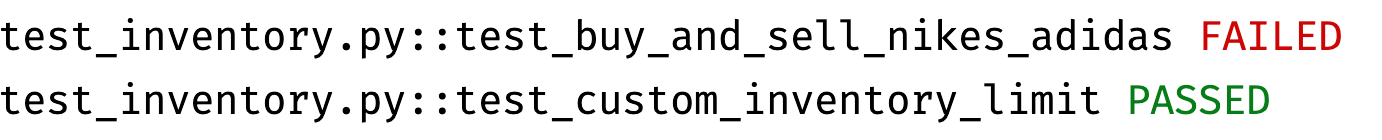

The integration fails, but the limit setting test passes. 


### On Fixtures

Did you notice that, our two tests required us to instantiate an Inventory object before we could begin? 


It is likely  that we shall have to do the same for all future tests - tedious and repetitive - `a bad smell`.

The medicine for this is  **fixtures**.
- A fixture is a known and fixed state that tests are run against to ensure that results are repeatable.

**Key good practice:-** tests should run in isolation of each other. The results of one test case shouldn't affect the results of another test case.

### Creating our first fixture
-  an Inventory object with no stock

In the test module `test_inventory.py`, add this at the top of the module:

In [ ]:
import pytest

@pytest.fixture
def no_stock_inventory():
    """Returns an empty inventory that can store 10 items"""
    return Inventory(10)

#### Thoughts
- `pytest.fixture` decorator is used. 
- for testing purposes we can reduce the inventory limit to 10.

**Question to you:** What is a decorator?

#### Using the fixture
- use the fixture to add a test for the `add_new_stock()` method:

In [ ]:
def test_add_new_stock_success(no_stock_inventory):
    no_stock_inventory.add_new_stock('Test Jacket', 10.00, 5)
    assert no_stock_inventory.total_items == 5
    assert no_stock_inventory.stocks['Test Jacket']['price'] == 10.00
    assert no_stock_inventory.stocks['Test Jacket']['quantity'] == 5

#### Reflections

- The name of the fixture function is the argument of the test - they must be the same name for the fixture to be applied. 

**How do we ensure the stock was added?**

- you need to test a bit more than the total items stored so far. 
- writing this test has forced us to consider how we display a stock's price and remaining quantity.


Run `pytest -v`  - there should be 2 failures and 1 pass. 

In the the Inventory class, add the `add_new_stock()` method:

In [ ]:
class Inventory:
    def __init__(self, limit=100):
        self.limit = limit
        self.total_items = 0
        self.stocks = {}

    def add_new_stock(self, name, price, quantity):
        self.stocks[name] = {
            'price': price,
            'quantity': quantity
        }
        self.total_items += quantity

 Run `pytest` - you get the output 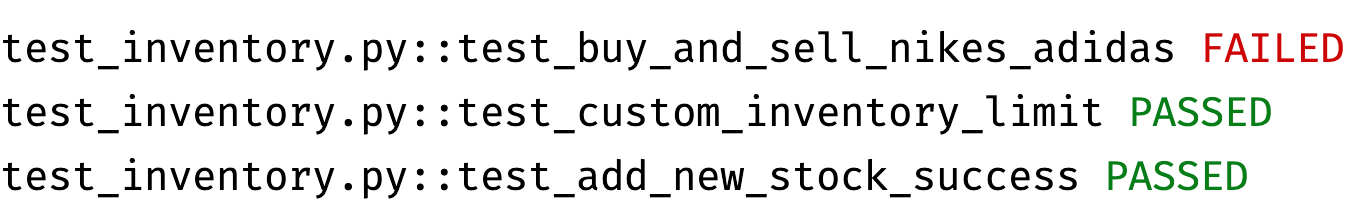

The `test_buy_and_sell_nikes_adidas` test is still failing.

In [ ]:
    def remove_stock(self, name, quantity):
        if quantity <= 0:
            raise InvalidQuantityException(
                'Cannot remove a quantity of {}. Must remove at least 1 item'.format(quantity))
        if name not in self.stocks:
            raise ItemNotFoundException(
                'Could not find {} in our stocks. Cannot remove non-existing stock'.format(name))
        if self.stocks[name]['quantity'] - quantity <= 0:
            raise InvalidQuantityException(
                'Cannot remove these {} items. Only {} items are in stock'.format(
                    quantity, self.stocks[name]['quantity']))
        self.stocks[name]['quantity'] -= quantity
        self.total_items -= quantity


## Diving deeper
#### Fixtures for databases

Using fixtures can be invaluable in setting up temporary databases to achieve a realistic and repeatable testing environment.

- Fixtures - objects that set up certain conditions that are then used in testing. 

We can think of them as functions that are called `before running the actual test functions`. In pytest, this can be done by marking a function with the decorator `@pytest.fixture`. 

Afterwards, you can use the fixture in any test function, simply by adding it as an argument to the function definition. 

**Example Fixture - 1**

Create a test module called `test_database.py`

This is an experimental module to demonstrate how to test a database application.

In [ ]:
import os
import pytest
import sqlite3


@pytest.fixture()
def db():
    conn = sqlite3.connect('mystock.db')
    conn.execute('CREATE TABLE if not exists stock (name TEXT, price float)')
    return conn


# setup
@pytest.fixture()
def test_sqlite(db):
    db.execute('INSERT INTO stock (name, price) VALUES ("car", 2000)')


# test 1
# @pytest.mark.skip
# @pytest.mark.skip(reason="cannot testing this for now")
def test_select_data(db, test_sqlite):
    c = db.execute('SELECT * FROM stock;')
    assert list(c) == [('car', 2000)]

    # test ...

    # test N


def test_select_where(db, test_sqlite):
    c = db.execute('SELECT * FROM stock WHERE name = "car";')
    #pytest.skip("not possible with d xyz")
    assert list(c) == [('car', 2000)]

@pytest.fixture()
def tearDown():
    os.remove('mystock.db')


def test_db_removed(db,tearDown):
    c = db.execute('SELECT * FROM stock WHERE name = "car";')
    # pytest.skip("not possible with d xyz")
    assert list(c) == []

### Reflection 
**What have we just done?**

- we imported some useful modules 
    - `os` to help us remove a file from the file system 
    - `sqlite3` to help us create a database 
    - `pytest` to help us create test fixtures

- function `db` is not a test function. It is a function, creates a database, and is decorated as fixture to be used by other functions
- function `test_sqlite` is a test function, that uses the fixture `db`. Furthermore, `test_sql_lite` is also a fixture
- `test_select_where` uses two fixture functions

**Questions for you:**
- what does the `tearDown` fixture do?
- what does the `test_db_removed` test do?

### Task

Consider this test module with the included test cases

Study the test cases and write the code to pass  the test.

Write one feature at a time, run the test until it passes before moving on to the next feature.

**How to proceed:**
- We need to follow the methodology.
1. Create a test module called `test_calculator.py` and place the test cases below in it
2. Run `pytest -v test_calculator.py` to see your tests failing. Note reasons given
3. Create an application module, `calculator.py` and in it create a class **Calculator**
4. Decide on the nature of your constructor. Then run pytest
5. Add your first method to enable your first test case to pass. Then run the test.

**Questions:**
- what does the fixture do?
- what does the helper do?

**Ignore the parameterization bits for now**


In [ ]:
import pytest
from calculator import Calculator

# Constants

NUMBER_1 = 3.0
NUMBER_2 = 2.0


# Fixtures

@pytest.fixture
def calculator():
    return Calculator()


# Helper

def verify_answer(expected, answer, last_answer):
    assert expected == answer
    assert expected == last_answer


# Test Cases

def test_last_answer_init(calculator):
    assert calculator.last_answer == 0.0


def test_add(calculator):
    answer = calculator.add(NUMBER_1, NUMBER_2)
    verify_answer(5.0, answer, calculator.last_answer)


def test_subtract(calculator):
    answer = calculator.subtract(NUMBER_1, NUMBER_2)
    verify_answer(1.0, answer, calculator.last_answer)


def test_subtract_negative(calculator):
    answer = calculator.subtract(NUMBER_2, NUMBER_1)
    verify_answer(-1.0, answer, calculator.last_answer)


def test_multiply(calculator):
    answer = calculator.multiply(NUMBER_1, NUMBER_2)
    verify_answer(6.0, answer, calculator.last_answer)


def test_divide(calculator):
    answer = calculator.divide(NUMBER_1, NUMBER_2)
    verify_answer(1.5, answer, calculator.last_answer)


def test_divide_by_zero(calculator):
    with pytest.raises(ZeroDivisionError) as e:
        calculator.divide(NUMBER_1, 0)
    assert "division by zero" in str(e.value)


@pytest.mark.parametrize("a,b,expected", [
    (NUMBER_1, NUMBER_2, NUMBER_1),
    (NUMBER_2, NUMBER_1, NUMBER_1),
    (NUMBER_1, NUMBER_1, NUMBER_1),
])
def test_maximum(calculator, a, b, expected):
    answer = calculator.maximum(a, b)
    verify_answer(expected, answer, calculator.last_answer)


@pytest.mark.parametrize("a,b,expected", [
    (NUMBER_1, NUMBER_2, NUMBER_2),
    (NUMBER_2, NUMBER_1, NUMBER_2),
    (NUMBER_2, NUMBER_2, NUMBER_2),
])
def test_minimum(calculator, a, b, expected):
    answer = calculator.minimum(a, b)
    verify_answer(expected, answer, calculator.last_answer)

   